## HW 2: Crossentropy method
_Reference: based on Practical RL course by YSDA_

In this notebook you have to solve two simple RL problems with crossentropy method.

To get used to `gymnasium` package, please, refer to the [documentation](https://gymnasium.farama.org/introduction/basic_usage/).


In the end of the notebook, please, copy the functions you have implemented to file `template_crossentropy.py` and submit it to the Contest.

In [1]:
import matplotlib.pyplot as plt
import gymnasium as gym
import numpy as np
import pandas as pd
%matplotlib inline

## Part 1. Tabular CrossEntropy
Let's consider discrete game "Taxi".

There are four designated pick-up and drop-off locations (Red, Green, Yellow and Blue) in the 5x5 grid world. The taxi starts off at a random square and the passenger at one of the designated locations.

The goal is move the taxi to the passenger’s location, pick up the passenger, move to the passenger’s desired destination, and drop off the passenger. Once the passenger is dropped off, the episode ends.

The player receives positive rewards for successfully dropping-off the passenger at the correct location. Negative rewards for incorrect attempts to pick-up/drop-off passenger and for each step where another reward is not received.

You can find full description of the environment [here](https://gymnasium.farama.org/environments/toy_text/taxi/).

![Taxi-v3](https://gymnasium.farama.org/_images/taxi.gif)

So here's how it works:

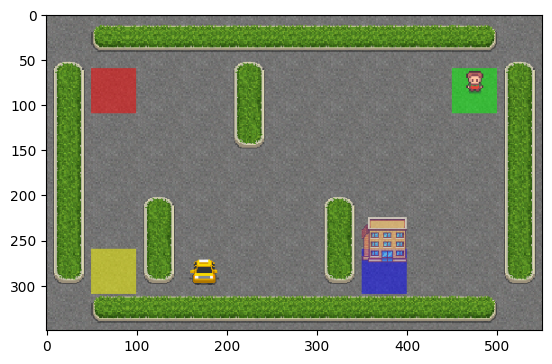

In [22]:
env = gym.make("Taxi-v3", render_mode="rgb_array")
init_obs, info = env.reset()

plt.imshow(env.render())

In [23]:
print(init_obs)
print(info)

427
{'prob': 1.0, 'action_mask': array([0, 1, 1, 0, 0, 0], dtype=int8)}


In [14]:
# env.close()

In [ ]:
obs_space = env.observation_space
act_space = env.action_space

print(f"obs_space={obs_space}, act_space={act_space}")

n_states = obs_space.n
n_actions = act_space.n

obs_space=Discrete(500), act_space=Discrete(6)


Let's make an action 1 and see what happens:

In [16]:
next_state, reward, is_done, _, _ = env.step(1)

In [17]:
print(f"We got to state {next_state}, the reward is {reward}, game is not finished because is_done={is_done}")

We got to state 86, the reward is -1, game is not finished because is_done=False


### Create stochastic policy

This time our policy should be a probability distribution.

```policy[s,a] = P(take action a | in state s)```

Since we still use integer state and action representations, you can use a 2-dimensional array to represent the policy.

Please initialize policy __uniformly__, that is, probabililities of all actions should be equal.


In [ ]:
policy_arr = np.ones((n_states, n_actions)) / n_actions

In [ ]:
assert type(policy_arr) in (np.ndarray, np.matrix)
assert np.allclose(policy_arr, 1./n_actions)
assert np.allclose(np.sum(policy_arr, axis=1), 1)

In [ ]:
policy_arr

array([[0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667],
       [0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667],
       [0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667],
       ...,
       [0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667],
       [0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667],
       [0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667]], shape=(500, 6))

In [ ]:
policy_arr.shape

(500, 6)

### Play the game

Just like before, but we also record all states and actions we took.

Sample the action (e.g. `np.random.choice()`) from available actions and make a step in the environment using `env.step()`.

In [61]:
from dataclasses import dataclass, field
from typing import Callable, Optional, Union, List
import numpy as np

# Тип стратегии
StrategyCallable = Callable[[int, Optional[List[int]]], int]  # state + optional history -> action
StrategyArray = np.ndarray                                      # [n_states, n_actions]
StrategyType = Union[StrategyCallable, StrategyArray]

@dataclass
class TrajectoryData:
    """Holds one episode trajectory generated by a PolicyAgent."""
    states: List[int]
    actions: List[int]
    rewards: List[float]
    total_reward: float = 0.0
    
    def __str__(self):
        lines = [
            f"TrajectoryData:",
            f"  total_reward: {self.total_reward}",
            f"  states ({len(self.states)}): {self.states}",
            f"  actions ({len(self.actions)}): {self.actions}",
            f"  rewards ({len(self.rewards)}): {self.rewards}",
        ]
        return "\n".join(lines)

@dataclass
class PolicyAgent:
    n_states: int
    n_actions: int
    _strategy: Optional[StrategyType] = None
    history_length: int = 0
    _state_history: List[int] = field(default_factory=list)

    def set_strategy(self, strategy: StrategyType):
        """Set the agent's strategy with validation."""
        if callable(strategy):
            self._strategy = strategy
        elif isinstance(strategy, np.ndarray):
            if strategy.shape != (self.n_states, self.n_actions):
                raise ValueError(f"Policy table must have shape ({self.n_states}, {self.n_actions})")
            if np.any(strategy < 0):
                raise ValueError("All probabilities must be non-negative")
            if not np.allclose(strategy.sum(axis=1), 1):
                raise ValueError("Probabilities for each state must sum to 1")
            self._strategy = strategy
        else:
            raise TypeError("Strategy must be a callable or np.ndarray of shape [n_states, n_actions]")

    def reset_history(self):
        self._state_history.clear()

    def get_action(self, state: int) -> int:
        if callable(self._strategy):
            return self._strategy(state, self._state_history if self.history_length > 0 else None)
        elif isinstance(self._strategy, np.ndarray):
            probs = self._strategy[state]
            return np.random.choice(self.n_actions, p=probs)
        else:
            raise ValueError("Strategy not set. Call set_strategy() first.")

    def sample_trajectory(self, env, t_max: int = 1000) -> TrajectoryData:
        """
        Play one episode using the current policy in the given environment.
        Returns a TrajectoryData object.
        """
        states, actions, rewards = [], [], []
        s, info = env.reset()
        self.reset_history()

        for t in range(t_max):
            a = self.get_action(s)
            new_s, r, done, truncated, info = env.step(a)

            states.append(s)
            actions.append(a)
            rewards.append(r)

            s = new_s
            if done:
                break

        return TrajectoryData(states=states, actions=actions, rewards=rewards, total_reward=sum(rewards))


In [ ]:
policy_arr: StrategyArray = policy_arr

agent = PolicyAgent(history_length=0, 
                    n_actions=n_actions, 
                    n_states=n_states, 
                    )

agent.set_strategy(strategy=policy_arr)

trajectory: TrajectoryData = agent.sample_trajectory(env=env)

print(trajectory)

TrajectoryData:
  total_reward: -3907
  states (1000): [343, 243, 243, 223, 123, 123, 123, 123, 23, 23, 23, 23, 3, 103, 203, 203, 203, 203, 103, 103, 103, 103, 103, 123, 123, 123, 123, 103, 103, 103, 123, 123, 223, 123, 223, 323, 423, 323, 423, 423, 423, 323, 323, 423, 423, 423, 423, 423, 423, 323, 223, 123, 123, 103, 103, 103, 103, 103, 3, 3, 3, 3, 19, 19, 3, 3, 3, 3, 3, 23, 23, 23, 23, 23, 23, 3, 23, 3, 3, 3, 3, 3, 3, 3, 3, 23, 23, 3, 3, 3, 3, 3, 3, 3, 3, 23, 3, 3, 103, 123, 223, 323, 343, 323, 323, 223, 223, 223, 223, 323, 323, 423, 423, 423, 323, 323, 223, 223, 223, 223, 223, 203, 203, 103, 203, 203, 103, 103, 3, 103, 103, 203, 303, 303, 303, 303, 303, 403, 403, 403, 403, 403, 403, 403, 303, 303, 303, 303, 303, 303, 303, 403, 403, 303, 303, 303, 303, 203, 203, 103, 203, 303, 303, 303, 303, 303, 303, 403, 303, 203, 303, 303, 303, 303, 303, 303, 303, 303, 303, 403, 403, 303, 403, 403, 403, 403, 403, 303, 303, 403, 303, 303, 303, 303, 303, 303, 203, 103, 103, 203, 103, 103, 103, 103, 

In [72]:
def generate_session(policy_agent: PolicyAgent, t_max=int(10**4)):
    """
    Play game until end or for t_max ticks.
    :param policy: an array of shape [n_states,n_actions] with action probabilities
    :returns: list of states, list of actions and sum of rewards
    """
    states, actions = [], []
    total_reward = 0.

    s, info = env.reset()

    for t in range(t_max):
        
        a = policy_agent.get_action(state=s)

        new_s, r, done, truncated, info = env.step(a)
        assert new_s is not None and r is not None and done is not None
        assert a is not None
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if done:
            break
    return states, actions, total_reward

In [73]:
s, a, r = generate_session(policy_agent=agent)
assert type(s) == type(a) == list
assert len(s) == len(a)
assert type(r) in [float, np.float64]

In [74]:
print(s, a, r, sep='\n================\n')

[171, 191, 191, 91, 71, 91, 91, 91, 91, 91, 191, 191, 91, 71, 71, 71, 91, 71, 71, 51, 51, 51, 71, 71, 171, 171, 271, 171, 171, 191, 91, 91, 191, 91, 91, 91, 91, 91, 91, 71, 71, 71, 91, 91, 71, 91, 191, 291, 291, 291, 291, 191, 191, 191, 91, 91, 71, 71, 171, 151, 151, 151, 151, 151, 251, 251, 231, 231, 231, 231, 331, 331, 431, 431, 431, 431, 431, 431, 331, 231, 331, 231, 231, 211, 211, 211, 211, 311, 311, 311, 211, 311, 411, 411, 411, 311, 311, 411, 411, 311, 311, 211, 211, 211, 211, 211, 211, 211, 211, 231, 211, 211, 211, 211, 311, 311, 311, 311, 311, 311, 311, 411, 419, 419, 319, 419, 319, 319, 319, 419, 419, 419, 419, 411, 411, 411, 411, 411, 411, 311, 311, 311, 311, 411, 411, 411, 411, 411, 411, 411, 419, 419, 419, 419, 419, 419, 411, 411, 411, 411, 411, 419, 419, 419, 419, 419, 419, 419, 419, 419, 419, 411, 311, 211, 311, 211, 211, 111, 111, 131, 131, 31, 31, 11, 111, 11, 11, 11, 11, 11, 11, 11, 31, 31, 131, 131, 111, 111, 11, 31, 131, 131, 231, 231, 211, 211, 211, 211, 111, 111, 1

In [81]:
# let's see the initial reward distribution
import matplotlib.pyplot as plt
%matplotlib inline

# sample_rewards = [generate_session(policy_agent=agent, t_max=1000)[-1] for _ in range(200)]

# plt.hist(sample_rewards, bins=20)
# plt.vlines([np.percentile(sample_rewards, 50)], [0], [100], label="50'th percentile", color='green')
# plt.vlines([np.percentile(sample_rewards, 90)], [0], [100], label="90'th percentile", color='red')
# plt.legend()

In [82]:
def collect_total_rewards(agent, n_sessions=200, t_max=1000):
    """
    Run multiple sessions and return list of total rewards per session.

    :param agent: PolicyAgent
    :param n_sessions: number of episodes to simulate
    :param t_max: max steps per episode
    :returns: list of total rewards
    """
    total_rewards = []
    for _ in range(n_sessions):
        _, _, total_reward = generate_session(policy_agent=agent, t_max=t_max)
        total_rewards.append(total_reward)
    return total_rewards


In [83]:
def plot_reward_distribution(sample_rewards, percentiles=[50, 90], bins=20):
    """
    Draw histogram of rewards and mark percentiles.

    :param sample_rewards: list or np.ndarray of total rewards per session
    :param percentiles: list of percentiles to mark on the histogram
    :param bins: number of bins for the histogram
    """
    import matplotlib.pyplot as plt

    plt.hist(sample_rewards, bins=bins, alpha=0.7)
    ymin, ymax = plt.ylim()
    
    for p in percentiles:
        value = np.percentile(sample_rewards, p)
        plt.vlines([value], ymin, ymax, label=f"{p}'th percentile", colors='red' if p>50 else 'green')
    
    plt.legend()
    plt.xlabel("Total reward per session")
    plt.ylabel("Number of sessions")
    plt.title("Reward distribution")
    plt.show()


CPU times: user 5.5 s, sys: 0 ns, total: 5.5 s
Wall time: 5.41 s


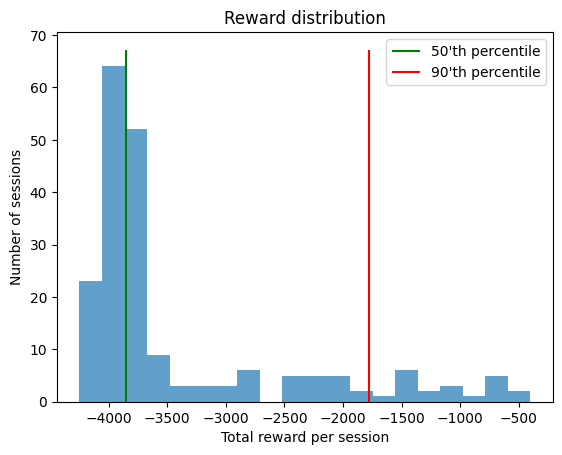

In [86]:
sample_rewards = _
%time sample_rewards = collect_total_rewards(agent, n_sessions=200, t_max=1000)

sample_rewards = [generate_session(env=env, policy=policy, t_max=1000)[-1] for _ in range(200)]

plot_reward_distribution(sample_rewards=sample_rewards)

In [97]:
np.percentile(sample_rewards, 50)
#np.percentile([], 50)

np.float64(-3853.0)

### Crossentropy method steps

In [133]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    if not (len(states_batch) == len(actions_batch) and len(actions_batch) == len(rewards_batch)):
        raise Exception("Batches must have equal first dimension")
    
    if len(rewards_batch) == 0:
        return [], []

    r_threshold = np.percentile(a=rewards_batch, q=percentile)

    elite_states = []
    elite_actions = []

    for session_i, r in enumerate(rewards_batch):
        if r >= r_threshold:
            elite_states.extend(states_batch[session_i])
            elite_actions.extend(actions_batch[session_i])

    return elite_states, elite_actions

In [134]:
states_batch = [
    [1, 2, 3],     # game1
    [4, 2, 0, 2],  # game2
    [3, 1],        # game3
]

actions_batch = [
    [0, 2, 4],     # game1
    [3, 2, 0, 1],  # game2
    [3, 3],        # game3
]
rewards_batch = [
    3,  # game1
    4,  # game2
    5,  # game3
]

test_result_0 = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=0)
test_result_40 = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=30)
test_result_90 = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=90)
test_result_100 = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=100)

assert np.all(test_result_0[0] == [1, 2, 3, 4, 2, 0, 2, 3, 1])  \
    and np.all(test_result_0[1] == [0, 2, 4, 3, 2, 0, 1, 3, 3]),\
    "For percentile 0 you should return all states and actions in chronological order"
assert np.all(test_result_40[0] == [4, 2, 0, 2, 3, 1]) and \
    np.all(test_result_40[1] == [3, 2, 0, 1, 3, 3]),\
    "For percentile 30 you should only select states/actions from two first"
assert np.all(test_result_90[0] == [3, 1]) and \
    np.all(test_result_90[1] == [3, 3]),\
    "For percentile 90 you should only select states/actions from one game"
assert np.all(test_result_100[0] == [3, 1]) and\
    np.all(test_result_100[1] == [3, 3]),\
    "Please make sure you use >=, not >. Also double-check how you compute percentile."
print("Ok!")

Ok!


In [ ]:
from collections import defaultdict
from itertools import product


def update_policy(elite_states: list, elite_actions: list, n_states: np.int64, n_actions: np.int64):
    """
    Given old policy and a list of elite states/actions from select_elites,
    return new updated policy where each action probability is proportional to

    policy[s_i,a_i] ~ #[occurences of si and ai in elite states/actions]

    Don't forget to normalize policy to get valid probabilities and handle 0/0 case.
    In case you never visited a state, set probabilities for all actions to 1./n_actions

    :param elite_states: 1D list of states from elite sessions
    :param elite_actions: 1D list of actions from elite sessions
    """

    s_a_freq = defaultdict(int)
    s_freq = defaultdict(int)

    for elite_s, elite_a in zip(elite_states, elite_actions):
        s_a_freq[elite_s,elite_a] += 1
        s_freq[elite_s] += 1

    n_states, n_actions = int(n_states), int(n_actions) 
    policy_shape = (n_states, n_actions)
    policy = np.zeros(policy_shape, dtype=np.float64)

    for s, a in product(range(n_states), range(n_actions)):
        policy[s,a] = s_a_freq[s,a]

    for s in range(policy_shape[0]):
        if (s_cnt := s_freq[s]) > 0:
            policy[s, :] /= s_cnt
        else: 
            policy[s, :] = 1. / n_actions

    return policy

In [ ]:
elite_states = [1, 2, 3, 4, 2, 0, 2, 3, 1]
elite_actions = [0, 2, 4, 3, 2, 0, 1, 3, 3]

new_policy = update_policy(elite_states=elite_states, elite_actions=elite_actions, n_actions=n_actions, n_states=n_states)

assert np.isfinite(new_policy).all(
), "Your new policy contains NaNs or +-inf. Make sure you don't divide by zero."
assert np.all(
    new_policy >= 0), "Your new policy can't have negative action probabilities"
assert np.allclose(new_policy.sum(
    axis=-1), 1), "Your new policy should be a valid probability distribution over actions"
reference_answer = np.array([
    [1.,  0.,  0.,  0.,  0.],
    [0.5,  0.,  0.,  0.5,  0.],
    [0.,  0.33333333,  0.66666667,  0.,  0.],
    [0.,  0.,  0.,  0.5,  0.5]])
assert np.allclose(new_policy[:4, :5], reference_answer)
print("Ok!")

[[1.         0.         0.         0.         0.         0.        ]
 [0.5        0.         0.         0.5        0.         0.        ]
 [0.         0.33333333 0.66666667 0.         0.         0.        ]
 ...
 [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
 [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
 [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]]
Ok!


### Training loop
Generate sessions, select N best and fit to those.

In [147]:
from IPython.display import clear_output

def show_progress(rewards_batch, log, percentile, reward_range):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f, percentile=%.3f" % (mean_reward, threshold, percentile))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label='Mean rewards')
    plt.plot(list(zip(*log))[1], label='Reward thresholds')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines([np.percentile(rewards_batch, percentile)],
               [0], [100], label="percentile", color='red')
    plt.legend()
    plt.grid()

    plt.show()

mean reward = -40.860, threshold=-50.502, percentile=30.936


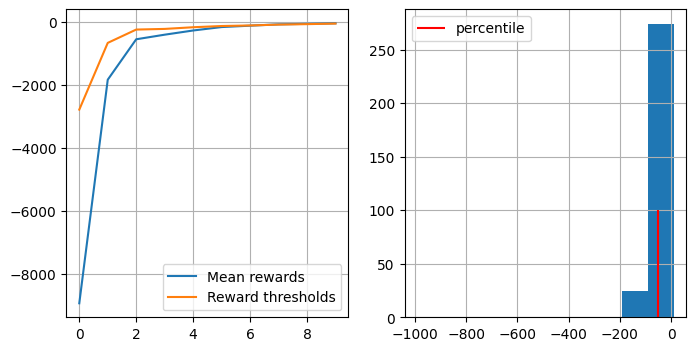

You Win!


In [ ]:
# reset policy just in case
policy_arr: StrategyArray = np.ones([n_states, n_actions]) / n_actions
agent.set_strategy(strategy=policy_arr)


n_sessions = 300  # sample this many sessions
percentile = 70  # take this percent of session with highest rewards
learning_rate = 0.8  # add this thing to all counts for stability

log = []

for i in range(100):

    %time sessions = [generate_session(policy_agent=agent) for _ in range(n_sessions)]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
    print(len(elite_states))

    new_policy = update_policy(elite_states=elite_states, elite_actions=elite_actions, n_actions=n_actions, n_states=n_states)

    policy_arr: StrategyArray = learning_rate*new_policy + (1-learning_rate)*policy_arr

    agent.set_strategy(strategy=policy_arr)

    # display results on chart
    reward_range = [-990, +10]
    show_progress(rewards_batch, log, percentile, reward_range=reward_range)

    mean_reward = np.mean(rewards_batch)
    target_mean_reward = -50

    mean_reward_diff = mean_reward - max(target_mean_reward, reward_range[0])

    diff_min, diff_max = reward_range
    perc_min, perc_max = 30, 80

    # обратная зависимость: хуже средняя награда → выше перцентиль
    percentile = perc_max - (mean_reward_diff - diff_min) * (perc_max - perc_min) / (diff_max - diff_min)
    percentile = np.clip(percentile, perc_min, perc_max)
    
    if mean_reward > target_mean_reward:
        print("You Win!")
        break

Congratulations! You've just trained your first RL model!
Now copy functions from this notebook to `template_crossentropy.py` and submit it to the Contest problem `Tabular CrossEntropy`.

## Part 2: Approximate crossentropy and neural nets.

In this section you will train a neural network policy for continuous state space game

You can find full description of the environment [here](https://www.gymlibrary.dev/environments/classic_control/cart_pole/).

![CartPole-v0"](https://www.gymlibrary.dev/_images/cart_pole.gif)

So here's how it works:

In [18]:
import gymnasium as gym
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v0", render_mode="rgb_array").env

env.reset()

n_actions = env.action_space.n
print(f"n_actions: {n_actions}")

env.observation_space.low
env.observation_space.high
type(env.observation_space)

n_actions: 2


gymnasium.spaces.box.Box

In [140]:
class RunningStats:
    """В online обновляем mean, var, не храня все данные"""
    
    def __init__(self, shape, epsilon=1e-8):
        self.mean = np.zeros(shape, dtype=np.float32)
        self.var = np.ones(shape, dtype=np.float32)
        self.count = 0
        self.epsilon = epsilon

    def update(self, x):
        batch_mean = np.mean(x, axis=0)
        batch_var  = np.var(x, axis=0)
        batch_count = x.shape[0]

        tot_count = self.count + batch_count
        delta = batch_mean - self.mean

        new_mean = self.mean + delta * batch_count / tot_count
        m_a = self.var * self.count
        m_b = batch_var * batch_count
        M2 = m_a + m_b + delta**2 * self.count * batch_count / tot_count
        new_var = M2 / tot_count

        self.mean = new_mean
        self.var = new_var
        self.count = tot_count

    def normalize(self, x):
        return (x - self.mean) / (np.sqrt(self.var) + self.epsilon)


In [141]:
env.observation_space.shape

(4,)

In [142]:
import numpy as np
from enum import Enum, auto

class VelocityNormalizeStrategy(Enum):
    None_ = auto()
    Tanh = auto()
    Running = auto()


class EnvWrapper:
    def __init__(self, 
                 env, 
                 normalize_state: bool = True, 
                 velocity_strategy: VelocityNormalizeStrategy = VelocityNormalizeStrategy.Tanh):
        """
        Gym environment wrapper with optional observation normalization [-1, 1].
        Velocities are scaled via tanh; terminate conditions are applied.

        :param env: gym.Env instance
        :param normalize_state: If True, normalize observations
        """
        self.env = env
        self.normalize_state = normalize_state
        self.velocity_strategy = velocity_strategy

        self.states_shape = getattr(env.observation_space, "shape", None)
        self.n_actions = getattr(env.action_space, "n", None)

        # observation bounds
        self.obs_high = env.observation_space.high.copy()
        self.obs_low  = env.observation_space.low.copy()

        # terminate thresholds
        self.terminate_cart = 2.4
        self.terminate_angle = 0.2095

        # Running stats for velocity
        if self.velocity_strategy == VelocityNormalizeStrategy.Running:
            self.velocity_stats = RunningStats(shape=2)

    def reset(self):
        """
        Reset the environment.

        :return obs: Normalized observation
        :return info: Environment info
        """
        obs, info = self.env.reset()
        return self._normalize_obs(obs), info

    def step(self, action: int):
        """
        Take a step in the environment.

        :param action: Discrete action (0 or 1)
        :return obs: Normalized observation
        :return reward: Step reward
        :return done: True if episode ended (bool)
        :return info: Environment info
        """
        new_obs, reward, done, trunc, info = self.env.step(action)

        return self._normalize_obs(new_obs), float(reward), bool(done or trunc), info

    def _normalize_obs(self, obs):
        """
        Normalize observation:
        - Finite bounds -> linear [-1, 1]
        - Velocity -> tanh scaling
        - Log velocity for debugging

        :param obs: Observation array
        :return: Normalized observation
        """
        obs = np.array(obs, dtype=np.float32)

        if self.normalize_state:
            # linear scaling for finite bounds (position and angle)
            finite_mask = np.isfinite(self.obs_high) & np.isfinite(self.obs_low)
            obs[finite_mask] = 2 * (obs[finite_mask] - self.obs_low[finite_mask]) / \
                               (self.obs_high[finite_mask] - self.obs_low[finite_mask]) - 1


            # velocity normalization
            velocity_mask = ~finite_mask
            velocities = obs[velocity_mask]

            if self.velocity_strategy == VelocityNormalizeStrategy.Tanh:
                obs[velocity_mask] = np.tanh(velocities)

            elif self.velocity_strategy == VelocityNormalizeStrategy.Running:
                velocities = velocities[None, :]  # shape (1, 2) for RunningStats
                self.velocity_stats.update(velocities)
                obs[velocity_mask] = self.velocity_stats.normalize(velocities).flatten()

            elif self.velocity_strategy == VelocityNormalizeStrategy.None_:
                pass

        return obs


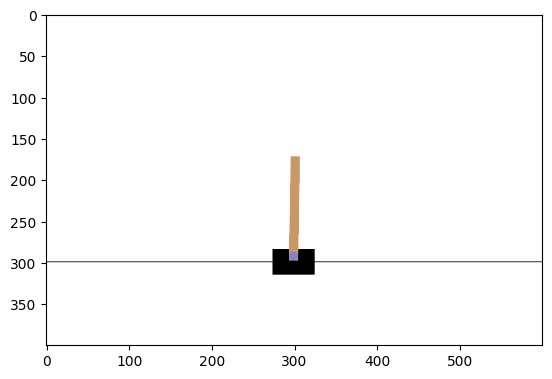

In [143]:
plt.imshow(env.render())

It is fine to use sklearn for such simple network, but we recommend you write the solution with PyTorch ;)

In [144]:
env_wrp = EnvWrapper(env=env, normalize_state=True, velocity_strategy=VelocityNormalizeStrategy.Running)

In [145]:
for a in range(n_actions):
    print(env_wrp.step(action=a))

(array([-3.4391880e-05,  0.0000000e+00,  2.4544597e-02,  0.0000000e+00],
      dtype=float32), 1.0, False, {})
(array([-7.1156025e-04,  9.9999982e-01,  4.0394902e-02, -9.9999988e-01],
      dtype=float32), 1.0, False, {})


In [165]:
from abc import ABC, abstractmethod
import numpy as np

class Actor(ABC):
    @abstractmethod
    def act(self, s: np.ndarray) -> int:
        ...

    def feed_step(self, new_s, r, done, info):
        """Optional: update online after every step"""
        pass

    def feed_session(self, states, actions, rewards):
        """Optional: update after one episode"""
        pass

    def feed_game(self, states_batch, actions_batch, rewards_batch):
        """Optional: update after batch of episodes"""
        pass


### Actor on contiguous space CEM

In [166]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np


class ActorNN(Actor):
    def __init__(self, state_dim, n_actions, hidden_size=128, lr=1e-3, device='cpu'):
        self.device = device
        self.model = nn.Sequential(
            nn.Linear(state_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions)
        ).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.n_actions = n_actions

    def act(self, s: np.ndarray) -> int:
        s_t = torch.FloatTensor(s).unsqueeze(0).to(self.device)
        logits = self.model(s_t)
        prob = F.softmax(logits, dim=-1)
        action = torch.multinomial(prob, 1).item()
        return action

    def feed_game(self, states_batch, actions_batch, rewards_batch, percentile):
        # Compute total reward per episode
        total_rewards = np.array([np.sum(r) for r in rewards_batch])
        reward_threshold = np.percentile(total_rewards, percentile)

        # Select elite episodes
        elite_states, elite_actions = [], []
        for s, a, r in zip(states_batch, actions_batch, rewards_batch):
            if np.sum(r) >= reward_threshold:
                elite_states.extend(s)
                elite_actions.extend(a)

        if not elite_states:
            return

        # Convert to tensors
        X = torch.FloatTensor(elite_states).to(self.device)
        y = torch.LongTensor(elite_actions).to(self.device)

        # Cross-entropy loss
        logits = self.model(X)
        loss = F.cross_entropy(logits, y)

        # Gradient step
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()


Update the generate_session function and beat the game!

In [167]:
def generate_session_cartpole(env_wrp: EnvWrapper, actor: Actor, t_max=300):

    states, actions, rewards = [], [], []
    total_reward = 0

    s, info = env_wrp.reset()

    for t in range(t_max):
        a = actor.act(s)

        new_s, r, done, info = env_wrp.step(a)

        actor.feed_step(new_s=new_s, r=r, done=done, info=info)

        states.append(s.astype(dtype=np.float32))
        actions.append(a)
        rewards.append(r)
        
        total_reward += r

        s = new_s
        if done:
            break

    actor.feed_session(states=states, actions=actions, rewards=rewards)

    return states, actions, rewards

In [ ]:
from IPython.display import clear_output

def show_progress(total_rewards, log, percentile, reward_range):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(total_rewards)
    threshold = np.percentile(total_rewards, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f, percentile=%.3f" % (mean_reward, threshold, percentile))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label='Mean rewards')
    plt.plot(list(zip(*log))[1], label='Reward thresholds')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(total_rewards, range=reward_range)
    plt.vlines([np.percentile(total_rewards, percentile)],
               [0], [100], label="percentile", color='red')
    plt.legend()
    plt.grid()

    plt.show()

In [176]:
env_wrp.states_shape[0]

4

In [177]:
env_wrp = EnvWrapper(
    env=env,
    normalize_state=True,
    velocity_strategy=VelocityNormalizeStrategy.None_
)

device = 'cpu'

actor = ActorNN(
    state_dim=env_wrp.states_shape[0], 
    device=device,
    hidden_size=128,
    n_actions=n_actions,
    lr=1e-3
)

In [178]:
def adjust_percentile(reward_mean, reward_range, perc_range):
    reward_min, reward_max = reward_range
    perc_min, perc_max = perc_range

    reward_diff = max(reward_mean - reward_min, 0)

    # обратная зависимость: хуже средняя награда → выше перцентиль
    percentile = perc_max - (perc_max - perc_min) * reward_diff / (reward_max - reward_min)
    
    return percentile


In [180]:
n_sessions = 100
percentile = 70
log = []
reward_range = [0, 200]
perc_range = [40,95]

for i in range(100):
    # generate new sessions
    sessions = [generate_session_cartpole(actor=actor, env_wrp=env_wrp) for _ in range(n_sessions)]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    actor.feed_game(states_batch=states_batch, actions_batch=actions_batch, rewards_batch=rewards_batch, percentile=percentile)
    
    total_rewards = [np.sum(rewards) for rewards in rewards_batch]
    reward_mean = np.mean(total_rewards)

    percentile = adjust_percentile(reward_range=reward_range, perc_range=perc_range, reward_mean=reward_mean)

    if max(total_rewards) > min(total_rewards):
        show_progress(total_rewards=total_rewards, log=log, percentile=percentile, reward_range=[0, np.max(total_rewards)])

    if reward_mean > 190:
        print("You Win!")
        break

KeyboardInterrupt: 

### Submission generation
To generate submission run the following block of code and submit the generated file to the contest problem `CrossEntropy CartPole`.

In [183]:
# DO NOT CHANGE THIS BLOCK
sessions = [generate_session_cartpole(env_wrp=env_wrp, actor=actor) for _ in range(n_sessions)]
# states_batch, actions_batch, rewards_batch = zip(*sessions)
# elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

sessions_to_send = []
for session in sessions:
  observations = [x.tolist() for x in session[0]]
  actions = [x for x in session[1]]
  sessions_to_send.append((observations, actions))

import json
with open('sessions_to_send.json', 'w') as iofile:
  json.dump(sessions_to_send, iofile, ensure_ascii=True, indent=4)
# DO NOT CHANGE THIS BLOCK